In [4]:
%pip install pandas pyarrow fastparquet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
from pathlib import Path

# Resolver rutas desde la carpeta raíz del proyecto (data-science)
proyecto_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
candidatos = [
    proyecto_root / "dataset" / "dataset_historico_2024-05-18.parquet",
    proyecto_root / "dataset" / "dataset.parquet",
]
ruta_dataset = next((p for p in candidatos if p.exists()), None)

nombre_archivo = str(ruta_dataset)
df = pd.read_parquet(nombre_archivo)

In [ ]:
# Definir las columnas que queremos analizar
columnas_interes = ['EstablecimientoCodigo', 'RegionCodigo', 'ComunaCodigo']

print("Tipos de datos detectados por Pandas:")
print(df[columnas_interes].dtypes)

Tipos de datos detectados por Pandas:


NameError: name 'columnas_interes' is not defined

In [ ]:
print("--- REPORTE DE DATOS INVÁLIDOS ---")

for col in columnas_interes:
    # 1. Hacemos una conversión "virtual" o temporal. 
    # Lo que no sea número se vuelve nulo temporalmente, pero el 'df' original queda intacto.
    simulacion = pd.to_numeric(df[col], errors='coerce')
    
    # 2. Comparamos: Buscamos filas que originalmente NO estaban vacías, 
    # pero que fallaron en la simulación matemática.
    datos_malos = df[(df[col].notnull()) & (simulacion.isnull())]
    
    # 3. Mostramos los resultados
    cantidad_errores = len(datos_malos)
    
    if cantidad_errores > 0:
        print(f"\n⚠️ PELIGRO: La columna '{col}' tiene {cantidad_errores} datos inválidos (no son números).")
        print("Aquí tienes los primeros 5 ejemplos de los datos problemáticos para que los veas:")
        # display() es perfecto en Jupyter para mostrar tablitas bonitas
        display(datos_malos[[col]].head()) 
    else:
        print(f"\n✅ La columna '{col}' está limpia. Todos sus textos son números válidos.")

--- REPORTE DE DATOS INVÁLIDOS ---

✅ La columna 'EstablecimientoCodigo' está limpia. Todos sus textos son números válidos.

✅ La columna 'RegionCodigo' está limpia. Todos sus textos son números válidos.

✅ La columna 'ComunaCodigo' está limpia. Todos sus textos son números válidos.


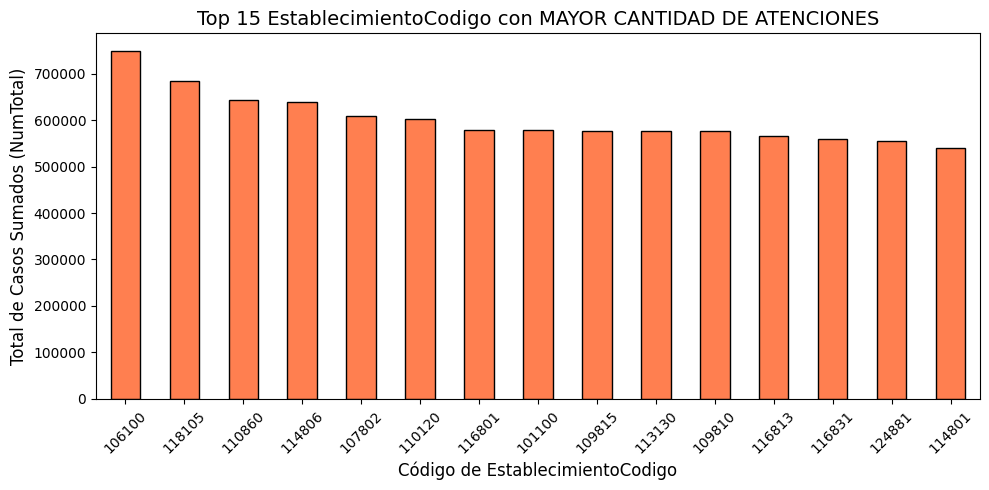

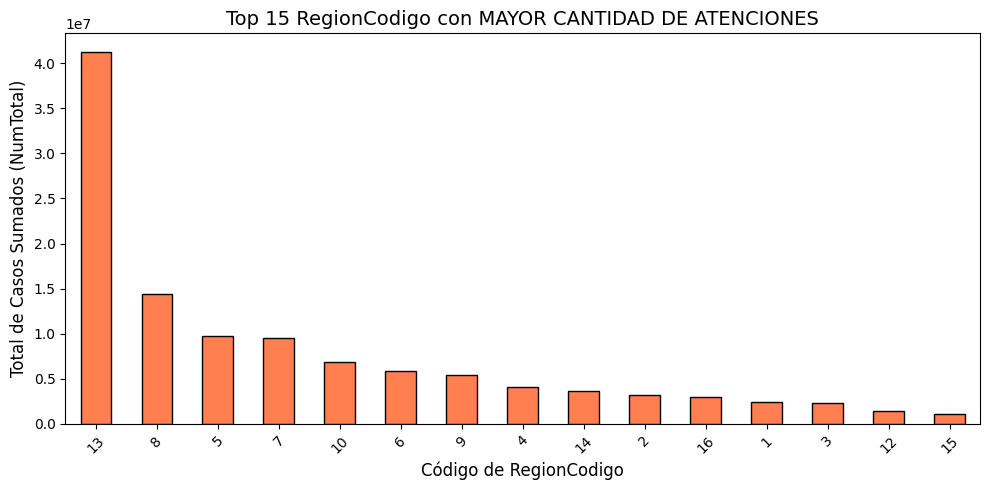

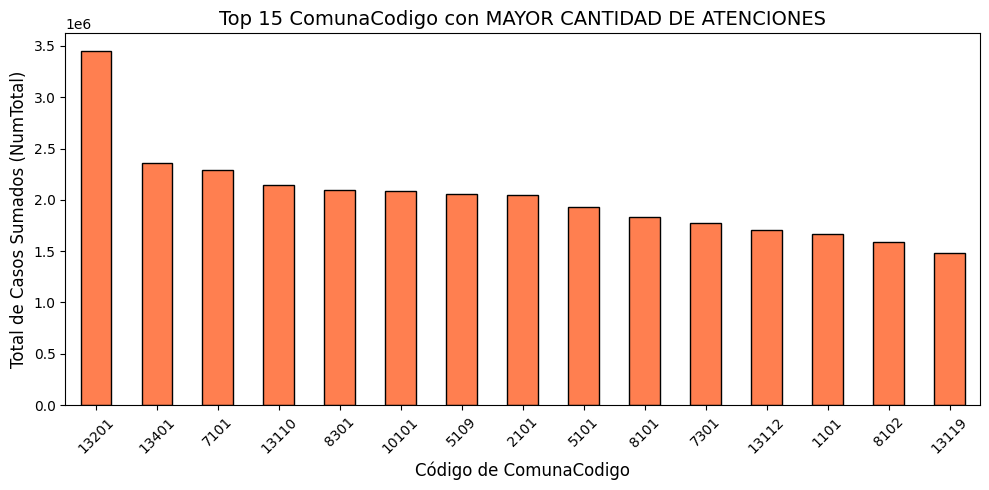

In [ ]:
import matplotlib.pyplot as plt

# Definir las columnas que queremos analizar
columnas_interes = ['EstablecimientoCodigo', 'RegionCodigo', 'ComunaCodigo']

# Crear un gráfico por cada columna usando un ciclo "for"
for col in columnas_interes:
    # 1. Agrupamos por la columna actual y SUMAMOS la columna 'NumTotal'
    atenciones = df.groupby(col)['NumTotal'].sum()
    
    # 2. Ordenamos de mayor a menor y sacamos el Top 15
    top_15 = atenciones.sort_values(ascending=False).head(15)
    
    # 3. Configurar el tamaño del gráfico (ancho, alto)
    plt.figure(figsize=(10, 5))
    
    # 4. Crear el gráfico de barras
    top_15.plot(kind='bar', color='coral', edgecolor='black')
    
    # 5. Agregar títulos y etiquetas dinámicas (usando la variable 'col')
    plt.title(f'Top 15 {col} con MAYOR CANTIDAD DE ATENCIONES', fontsize=14)
    plt.xlabel(f'Código de {col}', fontsize=12)
    plt.ylabel('Total de Casos Sumados (NumTotal)', fontsize=12)
    
    # 6. Rotar los números de abajo para que no se superpongan
    plt.xticks(rotation=45)
    
    # 7. Ajustar los márgenes y mostrar el gráfico
    plt.tight_layout()
    plt.show()

In [ ]:
# 1. Seleccionamos solo las columnas de interés y eliminamos las filas duplicadas
mapeo_regiones = df[['RegionCodigo', 'RegionGlosa']].drop_duplicates()

# 2. Ordenamos por el código de región para que sea más fácil de leer
mapeo_regiones = mapeo_regiones.sort_values('RegionCodigo').reset_index(drop=True)

# 3. Mostramos la tabla completa
print("Relación de Códigos y Nombres de Regiones:")
mapeo_regiones

Relación de Códigos y Nombres de Regiones:


,RegionCodigo,RegionGlosa
0,1,Región De Tarapacá
1,10,Región De Los Lagos
2,11,Región De Aysén del General Carlos Ibañez del ...
3,12,Región De Magallanes y de la Antártica Chilena
4,13,Región Metropolitana de Santiago
5,14,Región De Los Ríos
6,14,Región De los Ríos
7,15,Región De Arica Parinacota
8,16,Región De Ñuble
9,2,Región De Antofagasta


In [ ]:
# 1. Seleccionamos las columnas
mapeo_regiones = df[['RegionCodigo', 'RegionGlosa']]

# 2. Borramos duplicados fijándonos SOLO en el código numérico, conservando el primero que aparezca
mapeo_regiones_limpio = mapeo_regiones.drop_duplicates(subset=['RegionCodigo'], keep='first')

# 3. Ordenamos y reseteamos el índice
mapeo_regiones_limpio = mapeo_regiones_limpio.sort_values('RegionCodigo').reset_index(drop=True)

# 4. Mostramos el resultado
print("Diccionario de Regiones (Limpio):")
mapeo_regiones_limpio

Diccionario de Regiones (Limpio):


,RegionCodigo,RegionGlosa
0,1,Región De Tarapacá
1,10,Región De Los Lagos
2,11,Región De Aysén del General Carlos Ibañez del ...
3,12,Región De Magallanes y de la Antártica Chilena
4,13,Región Metropolitana de Santiago
5,14,Región De Los Ríos
6,15,Región De Arica Parinacota
7,16,Región De Ñuble
8,2,Región De Antofagasta
9,3,Región De Atacama


In [ ]:
# Diccionario de Comunas (Limpio)
mapeo_comunas = df[['ComunaCodigo', 'ComunaGlosa']]
mapeo_comunas_limpio = mapeo_comunas.drop_duplicates(subset=['ComunaCodigo'], keep='first')
mapeo_comunas_limpio = mapeo_comunas_limpio.sort_values('ComunaCodigo').reset_index(drop=True)
mapeo_comunas_limpio

,ComunaCodigo,ComunaGlosa
0,10101,Puerto Montt
1,10102,Calbuco
2,10104,Fresia
3,10105,Frutillar
4,10106,Los Muermos
...,...,...
303,9205,Lonquimay
304,9208,Purén
305,9210,Traiguén
306,9211,Victoria
